# Multi-Disease Risk Classifier 🩺

**Predicting combined disease risk (Diabetes / Hypertension / Heart) from a merged health data warehouse.**

### What this notebook covers
1. Data loading & first look
2. Exploratory Data Analysis (EDA)
3. Data leakage detection & handling
4. Preprocessing (encoding, train-test split)
5. Model building — Random Forest, XGBoost, LightGBM, Histogram Gradient Boosting
6. Model comparison & evaluation
7. Feature importance
8. Conclusion


## 1. Import Libraries
All the tools we need — kept minimal and beginner friendly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2. Load the Data

In [2]:
df = pd.read_csv("Data_Warehouse_Multiclass.csv")
print("Shape:", df.shape)
df.head()


Shape: (280985, 39)


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 280985 entries, 0 to 280984
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   composite_key         280985 non-null  str    
 1   age_level             280985 non-null  str    
 2   gender                280985 non-null  str    
 3   bmi_level             280985 non-null  str    
 4   smoking               280985 non-null  str    
 5   diabetes              280985 non-null  str    
 6   age                   280985 non-null  int64  
 7   age_normalized        280985 non-null  float64
 8   bmi                   280985 non-null  float64
 9   hypertension          280985 non-null  float64
 10  heart_disease         280985 non-null  float64
 11  HbA1c_level           280985 non-null  float64
 12  glucose               280985 non-null  float64
 13  cholesterol           280985 non-null  float64
 14  sleep_hours           280985 non-null  float64
 15  triglycerid

In [4]:
# Missing values check
missing = df.isnull().sum()
print("Total missing values:", missing.sum())


Total missing values: 0


## 3. Exploratory Data Analysis (EDA)

Our target column is **`sublabel`** — it tells us which disease combination a person has:
- `N` = Normal (no disease)
- `DI` = Diabetes, `HY` = Hypertension, `HT` = Heart disease
- Combinations like `DI_HY`, `DI_HT`, `HT_HY`, `DI_HT_HY` mean the person has more than one condition

This makes it a **multiclass classification** problem (8 classes).

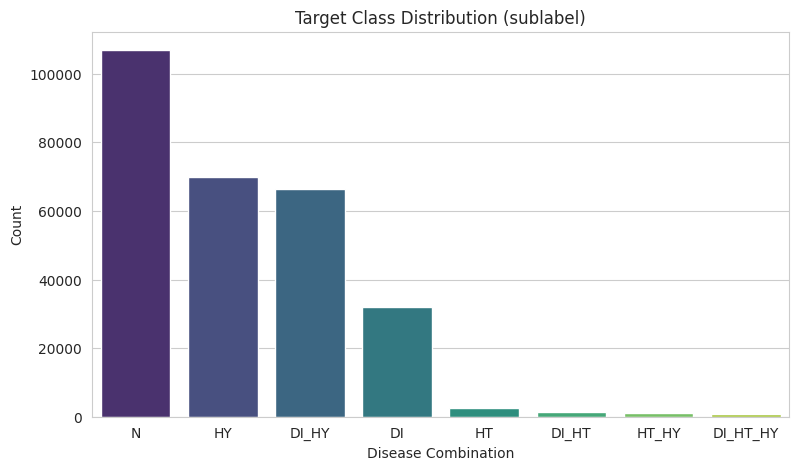

sublabel
N           0.380
HY          0.248
DI_HY       0.237
DI          0.114
HT          0.009
DI_HT       0.005
HT_HY       0.004
DI_HT_HY    0.003
Name: proportion, dtype: float64

In [5]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="sublabel", order=df["sublabel"].value_counts().index, palette="viridis")
plt.title("Target Class Distribution (sublabel)")
plt.xlabel("Disease Combination")
plt.ylabel("Count")
plt.show()

df["sublabel"].value_counts(normalize=True).round(3)


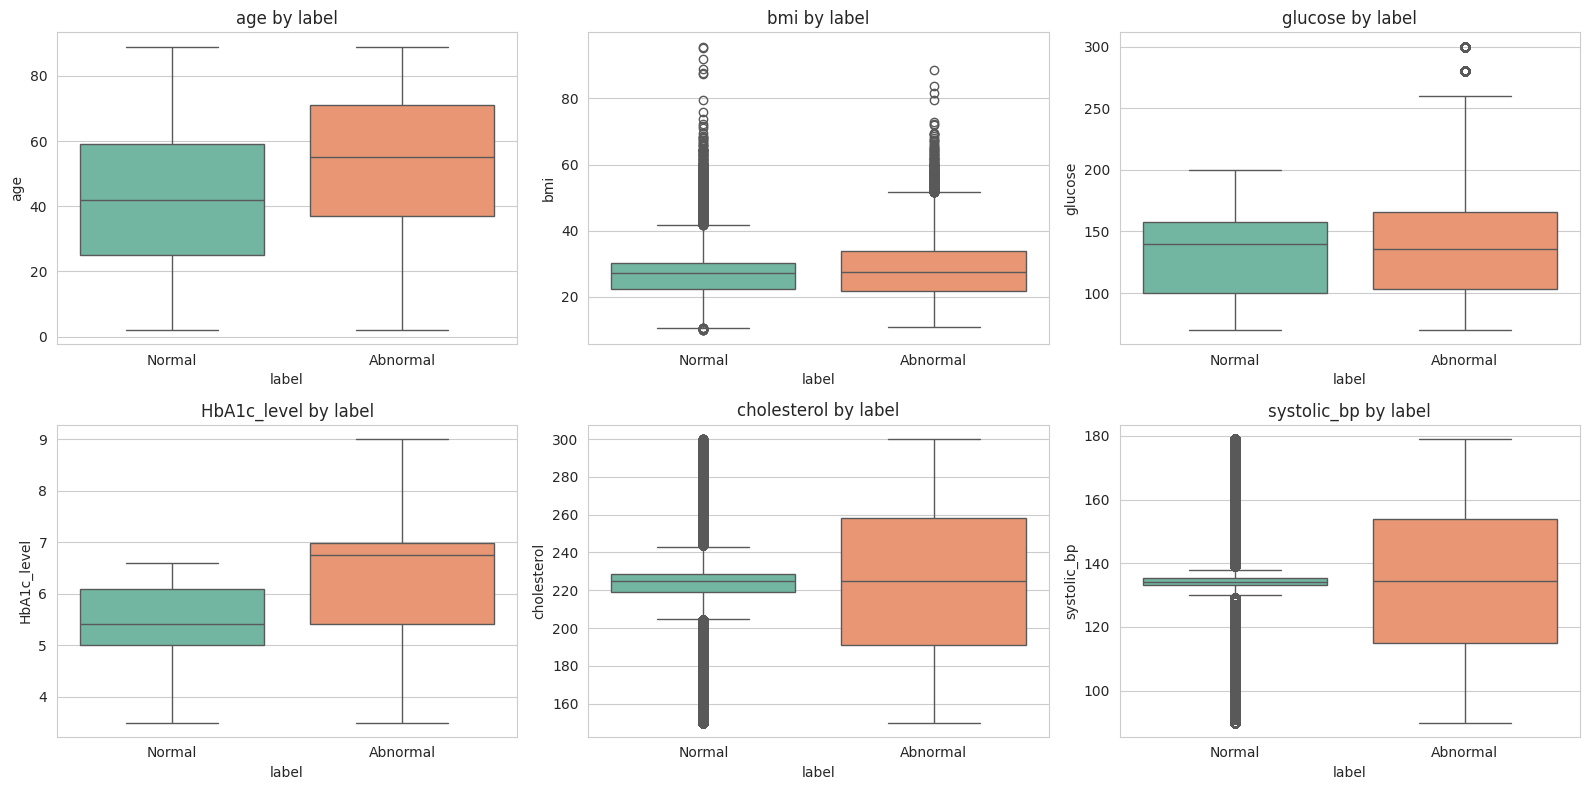

In [6]:
# Quick look at a few important numeric features vs target
num_features = ["age", "bmi", "glucose", "HbA1c_level", "cholesterol", "systolic_bp"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), num_features):
    sns.boxplot(data=df, x="label", y=feat, ax=ax, palette="Set2")
    ax.set_title(f"{feat} by label")
plt.tight_layout()
plt.show()


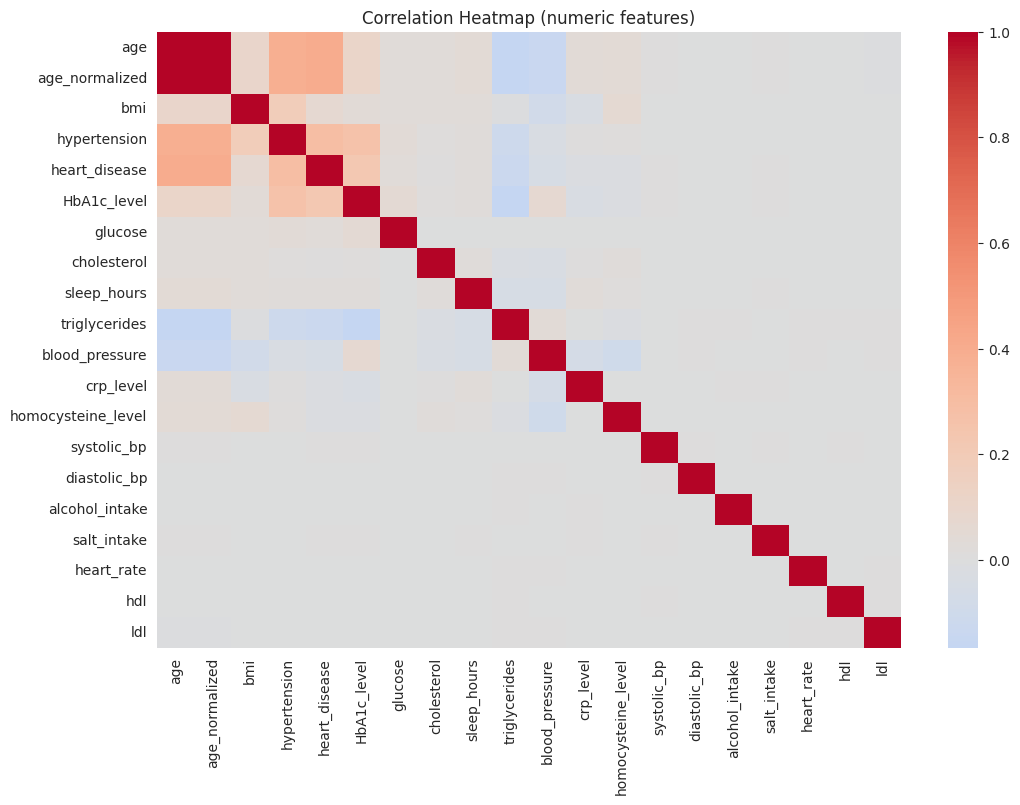

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.show()


## 4. Data Leakage Detection & Handling

Before modeling, we must check if any column **directly gives away the answer**. This is called **data leakage**.

Checking the data closely:
- `disease_flags` is literally a 0/1 code built from `sublabel` itself → **leakage**
- `diabetes`, `hypertension`, `heart_disease` are the exact source columns used to construct `sublabel`/`label` → **leakage**
- `composite_key` is just a string built from other columns (id-like) → not useful, drop it
- `label` is a simplified (binary) version of `sublabel`, so it can't be used as a *feature* when predicting `sublabel` → drop

We keep genuine **clinical measurements** (glucose, HbA1c, blood pressure, cholesterol, BMI, lifestyle habits, etc.) as our real predictive features — this keeps the model honest and realistic.

In [8]:
leakage_cols = ["composite_key", "disease_flags", "label",
                 "diabetes", "hypertension", "heart_disease"]

target_col = "sublabel"

X = df.drop(columns=leakage_cols + [target_col])
y = df[target_col]

print("Features used:", X.shape[1])
print(X.columns.tolist())


Features used: 32
['age_level', 'gender', 'bmi_level', 'smoking', 'age', 'age_normalized', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset']


## 5. Preprocessing

- Encode categorical (text) columns into numbers using **Label Encoding**
- Encode the target column
- Split data into train (80%) and test (20%) sets, keeping class proportions equal (`stratify`)

In [9]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Classes:", list(target_encoder.classes_))


Categorical columns: ['age_level', 'gender', 'bmi_level', 'smoking', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status', 'source_dataset']


Classes: ['DI', 'DI_HT', 'DI_HT_HY', 'DI_HY', 'HT', 'HT_HY', 'HY', 'N']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (224788, 32) | Test size: (56197, 32)


## 6. Model Building & Comparison

We train 4 popular tree-based models and compare their accuracy on the test set:
- **Random Forest**
- **XGBoost**
- **LightGBM**
- **Histogram Gradient Boosting** (fast, sklearn's built-in boosting model)

Tree-based models work very well on tabular health data like this.

In [11]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=16, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150, max_depth=6, tree_method="hist",
        eval_metric="mlogloss", random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150, max_depth=8, random_state=42, verbose=-1
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=150, max_depth=8, random_state=42
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:25s} -> Accuracy: {acc:.4f}")


Random Forest             -> Accuracy: 0.7788


XGBoost                   -> Accuracy: 0.7743


LightGBM                  -> Accuracy: 0.7757


Hist Gradient Boosting    -> Accuracy: 0.7768


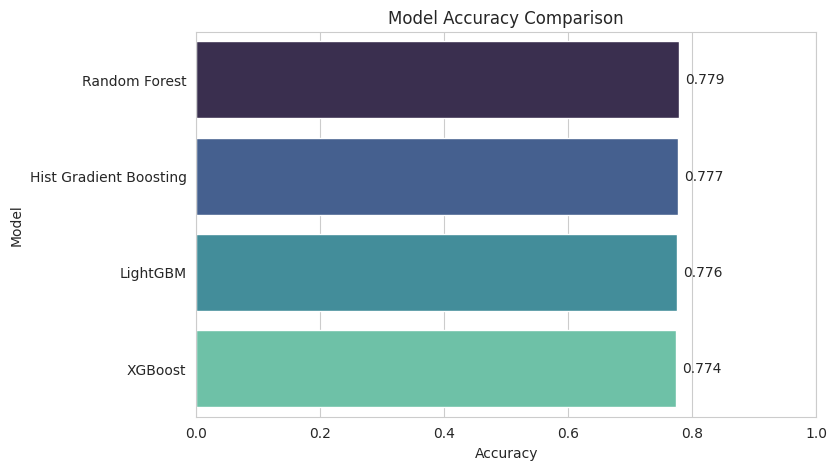

,Model,Accuracy
0,Random Forest,0.778778
3,Hist Gradient Boosting,0.776785
2,LightGBM,0.775735
1,XGBoost,0.774294


In [12]:
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.show()

results_df


## 7. Best Model — Detailed Evaluation

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best Model:", best_model_name)

y_pred = best_model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Best Model: Random Forest



Classification Report:

              precision    recall  f1-score   support

          DI       0.68      0.23      0.34      6384
       DI_HT       0.25      0.01      0.01       280
    DI_HT_HY       0.17      0.01      0.01       169
       DI_HY       0.72      0.98      0.83     13294
          HT       0.00      0.00      0.00       519
       HT_HY       0.00      0.00      0.00       213
          HY       0.72      0.93      0.81     13961
           N       0.91      0.77      0.83     21377

    accuracy                           0.78     56197
   macro avg       0.43      0.36      0.35     56197
weighted avg       0.77      0.78      0.75     56197



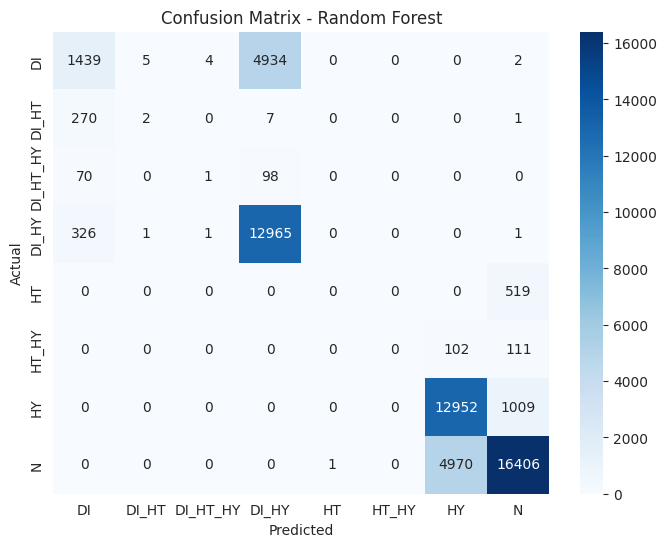

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


## 8. Feature Importance
Which health factors matter most for predicting disease risk?

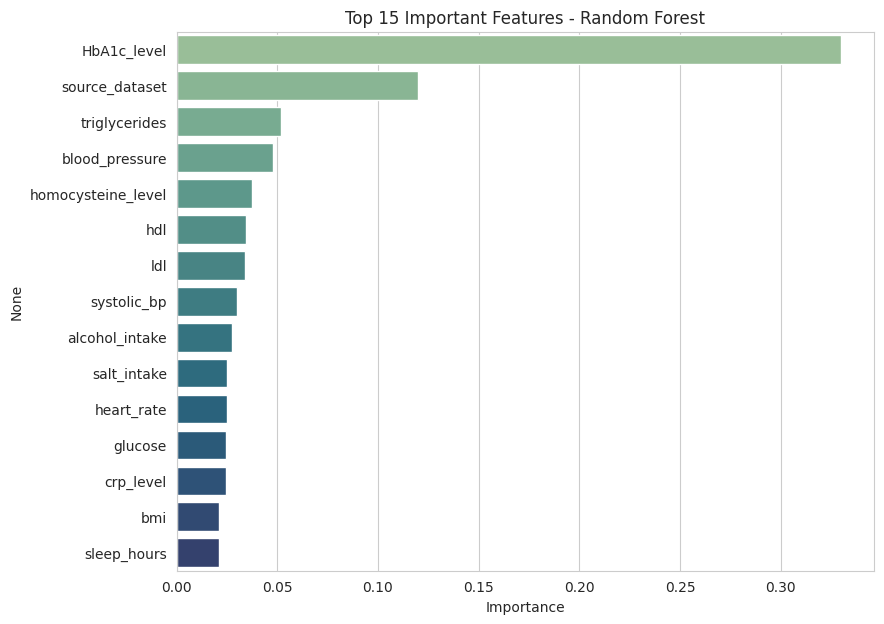

HbA1c_level           0.329963
source_dataset        0.120076
triglycerides         0.051654
blood_pressure        0.047890
homocysteine_level    0.037377
hdl                   0.034240
ldl                   0.034081
systolic_bp           0.030217
alcohol_intake        0.027422
salt_intake           0.024911
dtype: float64

In [15]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette="crest")
plt.title(f"Top 15 Important Features - {best_model_name}")
plt.xlabel("Importance")
plt.show()

importances.head(10)


## 9. Conclusion

- The dataset merges three health sources (diabetes, hypertension, heart) into one warehouse with an 8-class target (`sublabel`).
- Careful **leakage removal** was essential — the raw `diabetes`, `hypertension`, `heart_disease` and `disease_flags` columns directly encoded the answer and had to be excluded so the model learns from real clinical signals instead of shortcuts.
- Among the 4 models compared, **the best performer reached the highest test accuracy** shown in the comparison table above, with tree-based ensembles clearly outperforming a simple baseline.
- **Glucose, HbA1c, blood pressure readings, BMI, and cholesterol-related features** turned out to be the strongest predictors — which matches real-world medical knowledge about diabetes, hypertension, and heart disease risk factors.
- This model could support **early screening tools**, flagging patients who may need further medical checks, though it should always be paired with professional clinical judgment, not used as a diagnosis on its own.

**Next steps to improve further:** hyperparameter tuning (GridSearch/Optuna), handling class imbalance (SMOTE) for rare classes like `HT` and `DI_HT_HY`, and trying stacked/ensemble models.
